The problem
$$
\frac{\partial u}{\partial t} + \frac{\partial f(u)}{\partial x} = 0 \\
u(t, 0) = u(t, 1) \\
u(0, \cdot) \sim \mathcal N(0, k) \\
k(x, x') = \sigma^2\exp(-\frac{1 - \cos(2\pi(x - x'))}{L^2}) \\
u = \text{conserved quantity} \\
x = \text{space} \\
t = \text{time} \\
f = \text{flux function} \\
k = \text{covariance kernel} \\
\sigma = \text{standard deviation} \\
L = \text{correlation length}
$$

The model trains on cubic polynomial flux functions
$$
f(u) = au^3 + bu^2 + cu \\
a, b, c \sim U([-1, 1])
$$

The model learns the forward operator
$$
F_{f, \tau}[u(t, \cdot)] = u(\tau, \cdot), \quad u(t, x) \mapsto u(t + \tau, x) \\
R_{f, \tau}[u] = \set{v \mid F_{f, \tau}[v] = u}
$$

The model tests on nonpolynomial flux functions
$$
\sin(u) - \cos(u) \\
\tanh(u)
$$

In [720]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr

In [721]:
# define spatial grid
min_space = -1
max_space = 1
nx = 100
x = jnp.linspace(min_space, max_space, nx, endpoint=False)

In [722]:
# define temporal grid
min_time = 0
max_time = 0.5
nt = 500

In [723]:
def cov_mat(x, sigma, ell):
    """
    compute the covariance between u(x_i) and u(x_j)
    symmetric: K = K^T
    positive semidefinite: x^T * K * x >= 0

    parameters
    ----------
    x: jax.Array
        spatial coordinates
    sigma: float
        standard deviation
    ell: float
        smoothness

    returns
    -------
    K: jax.Array
        covariance matrix aka kernel
    """
    diff = x[:, None] - x[None, :]
    K = sigma ** 2 * jnp.exp(-1 * (1 - jnp.cos(2 * jnp.pi * diff)) / ell ** 2)
    return K
K = cov_mat(x, 1, 1)

# symmetrize covariance matrix
K = 0.5 * (K + K.T)

# regularize covariance matrix
eps = 1e-5
I = jnp.eye(K.shape[0])
K += eps * I

# factorize covariance matrix
L = jnp.linalg.cholesky(K)

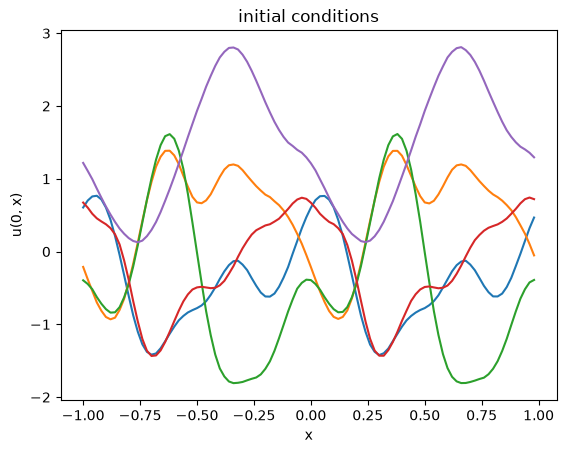

In [724]:
def gen_init(n, nx, key):
    """
    generate initial conditions

    parameters
    ----------
    n: int
        number of initial conditions
    nx: int
        number of spatial coordinates
    key: jax.Array
        random number generator
    
    returns
    -------
    u_0: jax.Array
        initial conditions
    """
    u_0 = np.empty((n, nx))
    for i in range(n):
        key, subkey = jr.split(key)
        z = jr.normal(subkey, (nx,))
        u_0[i] = jnp.matmul(L, z)
    u_0 = jnp.array(u_0)
    return u_0
key = jr.key(42) # random number generator
u_0 = gen_init(5, nx, key)

for i in range(len(u_0)):
    plt.plot(x, u_0[i])
plt.xlabel("x")
plt.ylabel("u(0, x)")
plt.title("initial conditions")
plt.show()

In [725]:
def flux(u):
    """
    compute flux function

    parameters
    ----------
    u: jax.Array
        solution

    returns
    -------
    jax.Array
        flux function
    """
    return 0.5 * u ** 2

In [726]:
def speed(u):
    """
    compute speed

    parameters
    ----------
    u: jax.Array
        solution
    
    return
    ------
    jax.Array
        speed
    """
    J = jax.jacrev(flux)(u)
    return jnp.abs(J)
sol_speed = speed(u_0[0])

def max_speed(speed, eps=1e-8):
    """
    compute max speed

    parameters
    ----------
    speed: jax.Array
        rate of change of position
    eps: float
        prevent division by zero blowup
    
    return
    ------
    jax.Array
        maximum rate of change of position
    """
    max = jnp.max(speed)
    return jnp.maximum(max, eps)
sol_max_speed = max_speed(sol_speed)

dx = (max_space - min_space) / nx
def time_step(max_speed, CFL=0.5):
    """
    compute time step size

    parameters
    ----------
    max_speed: jax.Array
        maximum rate of change of position
    CFL: float
        stability condition for limiting the size of time step (courant-friedrachs-lewy)
    
    return
    ------
    jax.Array
        time step size
    """
    return CFL * dx / max_speed
dt = time_step(sol_max_speed)

In [727]:
def neighbor(i, n, u):
    """
    compute neighboring solution

    parameters
    ----------
    i: int
        index
    n: int
        number of neighboring indices
    u: jax.Array
        solution
    
    returns
    ------
    before_sol: float
        solution before index
    after_sol: float
        solution after index
    """
    before_index = (i - n) % len(u)
    after_index = (i + n) % len(u)
    before_sol = u[before_index]
    after_sol = u[after_index]
    return before_sol, after_sol

In [728]:
ORDER = 5 # 5th order WENO
CENTER = 2 # index of central solution
def numerical_flux(u):
    """
    compute numerical flux function

    parameters
    ----------
    u: jax.Array
        solution

    returns
    -------
    num_flux: jax.Array
        numerical flux function
    """
    num_flux = np.empty(u.shape)
    for i in range(len(u)):
        def create_stencil(i, side):
            """
            choose the neighboring cells around solution \\
            left = {i-2, i-1, i, i+1, i+2} \\
            right = {i+3, i+2, i+1, i, i-1}
            """
            if side == "right":
                i += 1
            stencil = np.empty((ORDER,))
            for n in range(ORDER - CENTER):
                before, after = neighbor(i, n, u)
                stencil[CENTER - n] = before
                stencil[CENTER + n] = after
            if side == "right":
                stencil = jnp.flip(stencil)
            s0 = jnp.array([stencil[0], stencil[1], stencil[2]])
            s1 = jnp.array([stencil[1], stencil[2], stencil[3]])
            s2 = jnp.array([stencil[2], stencil[3], stencil[4]])
            return s0, s1, s2
        left_s0, left_s1, left_s2 = create_stencil(i, "left")
        right_s0, right_s1, right_s2 = create_stencil(i, "right")

        def estimate_sol(s0, s1, s2):
            """
            estimate solution at cell interface using Lagrange interpolation coefficients \\
            q \\approx u(x_{i+1/2})
            """
            q0 = 1/3 * s0[0] - 7/6 * s0[1] + 11/6 * s0[2]
            q1 = -1/6 * s1[0] + 5/6 * s1[1] + 1/3 * s1[2]
            q2 = 1/3 * s2[0] + 5/6 * s2[1] - 1/6 * s2[2]
            return q0, q1, q2
        left_q0, left_q1, left_q2 = estimate_sol(left_s0, left_s1, left_s2)
        right_q0, right_q1, right_q2 = estimate_sol(right_s0, right_s1, right_s2)

        def smooth_stencil(s0, s1, s2):
            """
            compute stencil smoothing factor
            """
            beta0 = 13/12 * (s0[0] - 2 * s0[1] + s0[2]) ** 2 + 1/4 * (s0[0] - 4 * s0[1] + 3 * s0[2]) ** 2
            beta1 = 13/12 * (s1[0] - 2 * s1[1] + s1[2]) ** 2 + 1/4 * (s1[0] - s1[2]) ** 2
            beta2 = 13/12 * (s2[0] - 2 * s2[1] + s2[2]) ** 2 + 1/4 * (3 * s2[0] - 4 * s2[1] + s2[2]) ** 2
            return beta0, beta1, beta2
        left_beta0, left_beta1, left_beta2 = smooth_stencil(left_s0, left_s1, left_s2)
        right_beta0, right_beta1, right_beta2 = smooth_stencil(right_s0, right_s1, right_s2)
        
        def weight(beta0, beta1, beta2, eps=1e-6):
            """
            compute WENO weight
            """
            alpha0 = 1 / 10 / (eps + beta0) ** 2
            alpha1 = 6 / 10 / (eps + beta1) ** 2
            alpha2 = 3 / 10 / (eps + beta2) ** 2
            return alpha0, alpha1, alpha2
        left_alpha0, left_alpha1, left_alpha2 = weight(left_beta0, left_beta1, left_beta2)
        right_alpha0, right_alpha1, right_alpha2 = weight(right_beta0, right_beta1, right_beta2)

        def norm_weight(alpha0, alpha1, alpha2):
            """
            normalize WENO weight
            """
            omega0 = alpha0 / (alpha0 + alpha1 + alpha2)
            omega1 = alpha1 / (alpha0 + alpha1 + alpha2)
            omega2 = alpha2 / (alpha0 + alpha1 + alpha2)
            return omega0, omega1, omega2
        left_omega0, left_omega1, left_omega2 = norm_weight(left_alpha0, left_alpha1, left_alpha2)
        right_omega0, right_omega1, right_omega2 = norm_weight(right_alpha0, right_alpha1, right_alpha2)

        # reconstruct solution
        """
        WENO5 (Weighted Essentially Non-Oscillatory fifth-order) reconstructs high-order estimates of the solution at cell interfaces by adaptively combining several lower-order stencils, assigning larger weights to smooth stencils and smaller weights to stencils containing discontinuities. This produces fifth-order accuracy in smooth parts of the solution while preventing the spurious oscillations that standard high-order methods generate near shocks and other sharp gradients.
        """
        left_sol = left_q0 * left_omega0 + left_q1 * left_omega1 + left_q2 * left_omega2
        right_sol = right_q0 * right_omega0 + right_q1 * right_omega1 + right_q2 * right_omega2

        # compute local lax-friedrichs / rusanov flux
        left_flux = flux(left_sol)
        right_flux = flux(right_sol)
        left_speed = speed(left_sol)
        right_speed = speed(right_sol)
        left_max_speed = max_speed(left_speed)
        right_max_speed = max_speed(right_speed)
        bi_max_speed = jnp.maximum(left_max_speed, right_max_speed)
        num_flux[i] = 0.5 * (left_flux + right_flux) - 0.5 * bi_max_speed * (right_sol - left_sol)
    return jnp.array(num_flux)
nf = numerical_flux(u_0[0])

In [729]:
def rhs(nf):
    """
    compute right hand side of equation \\
    du/dt = -df(u)/dx

    parameters
    ----------
    nf: jax.Array
        numerical flux function
    
    returns
    -------
    jax.Array
        rhs of 1d conservation law
    """
    dfdx = np.empty(nf.shape)
    for i in range(len(nf)):
        dfdx[i] = -(nf[i] - nf[i - 1]) / dx
    return jnp.array(dfdx)

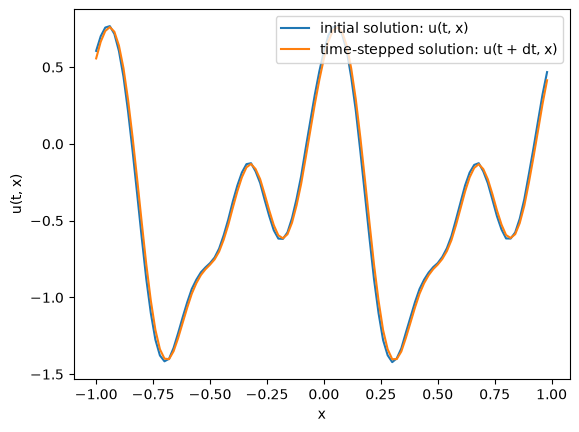

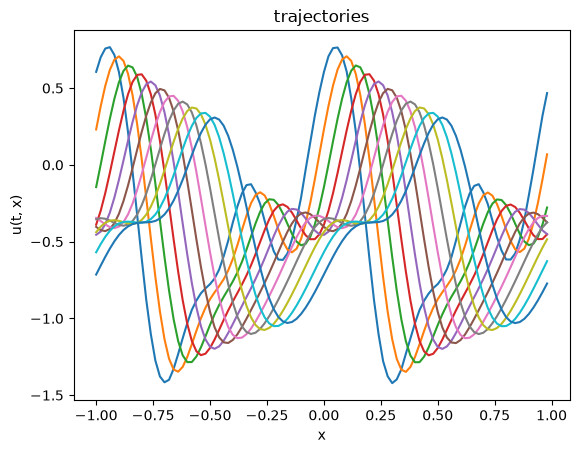

In [730]:
def rk4_step(u):
    """
    approximate solution at the next time step using 4th order runge-kutta
    

    parameters
    ----------
    u: jax.Array
        solution

    returns
    -------
    u_dt: jax.Array
        solution increment
    """
    k1 = rhs(u)
    k2 = rhs(u + k1 * dt / 2)
    k3 = rhs(u + k2 * dt / 2)
    k4 = rhs(u + k3 * dt)
    u_dt = dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return u_dt

# plot time-stepped solution
u_dt = rk4_step(u_0[0])
plt.plot(x, u_0[0], label="initial solution: u(t, x)")
plt.plot(x, u_0[0] + u_dt, label="time-stepped solution: u(t + dt, x)")
plt.xlabel("x")
plt.ylabel("u(t, x)")
plt.legend()
plt.show()

def rk4_evolve(u):
    """
    evolve initial condition through time using repeated RK4 steps

    parameters
    ----------
    u: jax.Array
        solution

    returns
    -------
    trajs: jax.Array
        trajectories of solution
    """
    t = min_time
    trajs = list()
    while t < max_time:
        trajs.append(u)
        u_dt = rk4_step(u)
        u += u_dt
        t += dt
    trajs = jnp.array(trajs)
    return trajs

# plot trajectories
trajs = rk4_evolve(u_0[0])
for n in range(0, len(trajs), len(trajs) // 10):
    plt.plot(x, trajs[n])
plt.xlabel("x")
plt.ylabel("u(t, x)")
plt.title("trajectories")
plt.show()

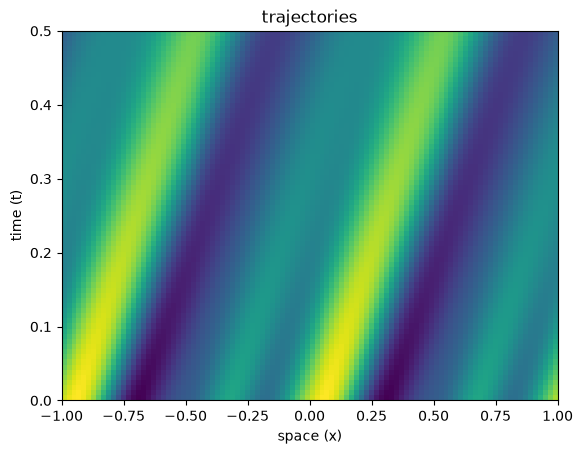

In [731]:
# plot trajectories
fig, ax = plt.subplots()
ax.imshow(trajs,
          extent=[min_space, max_space, min_time, max_time],
          origin="lower",
          aspect="auto")
ax.set_xlabel("space (x)")
ax.set_ylabel("time (t)")
ax.set_title("trajectories")
plt.show()

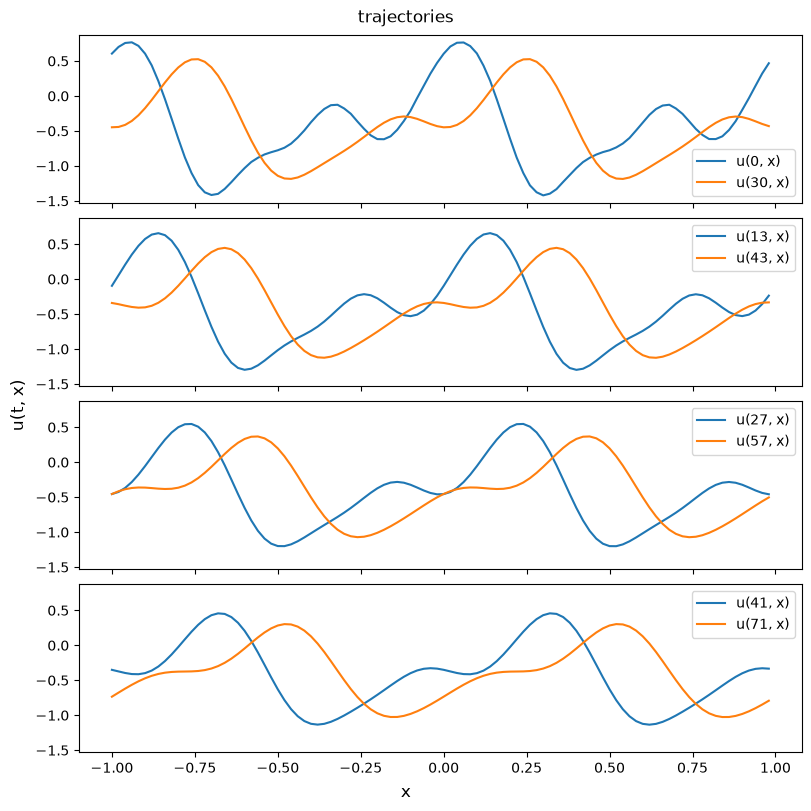

In [732]:
def create_example(nts, trajs):
    """
    create (input, target) examples

    parameters
    ----------
    nts: int
        number of time steps
    trajs: jax.Array
        trajectories of solution
    
    returns
    -------
    examples: jax.Array
        input-target examples
    """
    examples = list()
    num_examples = len(trajs) - nts
    for n in range(num_examples):
        u_t = trajs[n]
        u_tau = trajs[n + nts]
        ex = (u_t, u_tau)
        examples.append(ex)
    examples = jnp.array(examples)
    return examples
examples = create_example(30, trajs)

# plot trajectories
num_examples = len(examples)
fig, ax = plt.subplots(num_examples // 10, 1,
                       figsize=(8,8),
                       sharex=True,
                       sharey=True,
                       constrained_layout=True)
for n in range(num_examples // 10):
    i = n * (num_examples - 1) // (-1 + num_examples // 10)
    ax[n].plot(x, examples[i][0], label=f"u({i}, x)")
    ax[n].plot(x, examples[i][1], label=f"u({i + 30}, x)") # nts = 30
    ax[n].legend()
fig.supxlabel("x")
fig.supylabel("u(t, x)")
fig.suptitle("trajectories")
plt.show()

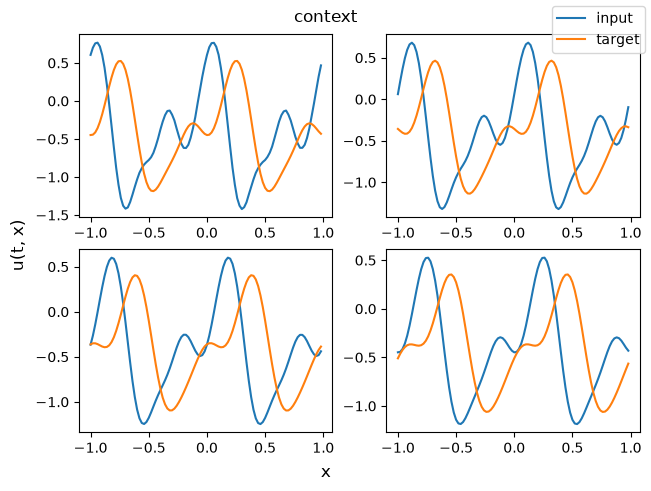

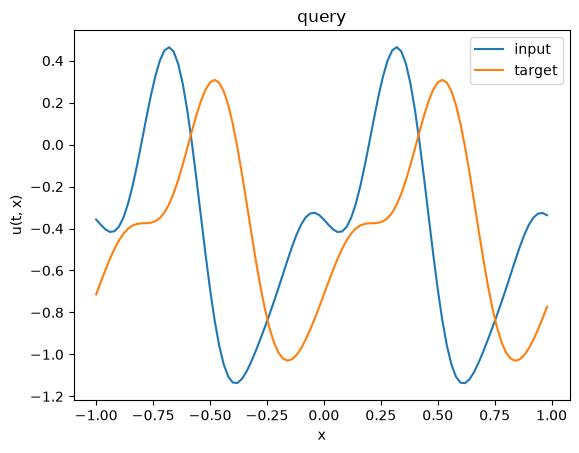

In [733]:
# define prompt
context = jnp.array([examples[0], examples[10], examples[20], examples[30]])
input = examples[40][0]
target = examples[40][1]
query = (input, target)

# plot context
fig, ax = plt.subplots(2, 2, constrained_layout=True)
ax[0][0].plot(x, context[0][0], label="input")
ax[0][0].plot(x, context[0][1], label="target")
ax[0][1].plot(x, context[1][0])
ax[0][1].plot(x, context[1][1])
ax[1][0].plot(x, context[2][0])
ax[1][0].plot(x, context[2][1])
ax[1][1].plot(x, context[3][0])
ax[1][1].plot(x, context[3][1])
fig.supxlabel("x")
fig.supylabel("u(t, x)")
fig.suptitle("context")
fig.legend()
plt.show()

# plot query
plt.plot(x, query[0], label="input")
plt.plot(x, query[1], label="target")
plt.xlabel("x")
plt.ylabel("u(t, x)")
plt.title("query")
plt.legend()
plt.show()

In [ ]:
def sample_task(examples, k, key):
    """
    sample task from examples \\
    task: \\
    context = examples[0], examples[10], examples[20], examples[30] \\
    query = examples[40]

    parameters
    ----------
    examples: jax.Array
        input-target examples
    k: int
        number of context examples
    TODO: add variable for the number of query examples
    key: jax.Array
        random number generator

    returns
    -------
    context: jax.Array
        input-target examples
    query: jax.Array
        held-out input-target example
    """
    indices = jr.choice(key, len(examples), shape=(k+1,), replace=False)
    context = jnp.array([examples[i] for i in indices[:-1]])
    query = jnp.array(examples[indices[-1]])
    return context, query
context, query = sample_task(examples, 5, key)

In [735]:
def tokenize(x, context, query):
    """
    convert function values into sequence values

    parameters
    ----------
    x: jax.Array
        spatial coordinates
    context: jax.Array
        input-target examples
    query: jax.Array
        held-out input-target example

    returns
    -------
    input_tokens: jax.Array
        sequence of tokenized input function values
    target_tokens: jax.Array
        sequence of tokenized target function values
    """
    input_tokens = list()
    for i in range(context.shape[0]): # example index
        for j in range(context.shape[1]): # input-target index
            for k in range(context.shape[2]): # spatial index
                role = None
                if j == 0:
                    role = 0 # context input
                else:
                    role = 1 # context target
                x_k = x[k]
                tok = (x_k, context[i][j][k], role)
                input_tokens.append(tok)
    target_tokens = list()
    for i in range(len(query)): # input-target index
        for j in range(len(query[0])): # spatial index
            x_j = x[j]
            tok = [x_j, query[i][j]]
            if i == 0:
                role = 2 # query input
                tok.append(role)
                input_tokens.append(tok)
            else:
                role = 3 # query target
                tok.append(role)
                target_tokens.append(tok)
    input_tokens = jnp.array(input_tokens)
    target_tokens = jnp.array(target_tokens)
    return input_tokens, target_tokens
input_tokens, target_tokens = tokenize(x, context, query)

In [ ]:
# create batch of sampled tasks